<a href="https://colab.research.google.com/github/aryancodes12/Advance-Machine-Learning/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
filepath = "/content/drive/MyDrive/CDPL SEM 3/dataset/Mall_Customers_simple.xlsx"

In [ ]:
import pandas as pd

data = pd.read_excel(filepath)

df = pd.DataFrame(data)

In [ ]:
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Annual Income (k$)      200 non-null    int64
 1   Spending Score (1-100)  200 non-null    int64
dtypes: int64(2)
memory usage: 3.3 KB


In [ ]:
df.shape

(200, 2)

In [ ]:
df.describe()

,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000
mean,60.560000,50.200000
std,26.264721,25.823522
min,15.000000,1.000000
25%,41.500000,34.750000
50%,61.500000,50.000000
75%,78.000000,73.000000
max,137.000000,99.000000


In [ ]:
df.columns

Index(['Annual Income (k$)', 'Spending Score (1-100)'], dtype='object')

In [ ]:
df.isnull().sum()

,0
Annual Income (k$),0
Spending Score (1-100),0


# Visualization

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

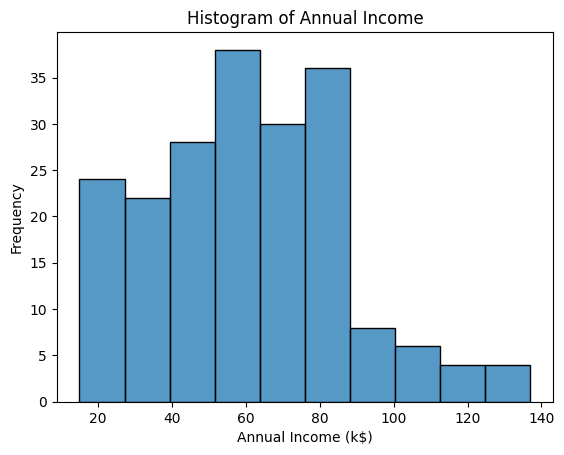

In [ ]:
sns.histplot(df['Annual Income (k$)'])
plt.title("Histogram of Annual Income")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")
plt.show()

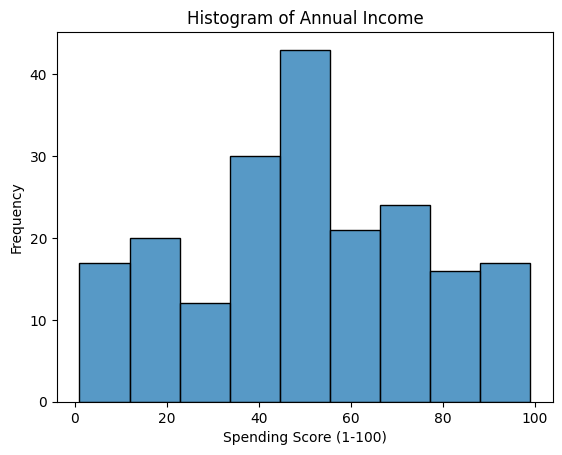

In [ ]:
sns.histplot(df['Spending Score (1-100)'])
plt.title("Histogram of Annual Income")
plt.xlabel("Spending Score (1-100)")
plt.ylabel("Frequency")
plt.show()

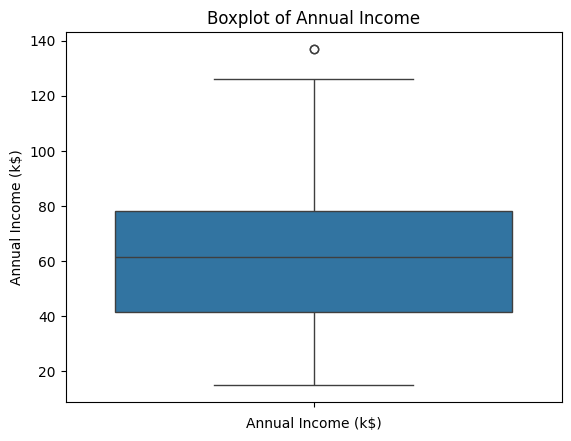

In [ ]:
sns.boxplot(df['Annual Income (k$)'])
plt.title("Boxplot of Annual Income")
plt.xlabel("Annual Income (k$)")
plt.show()

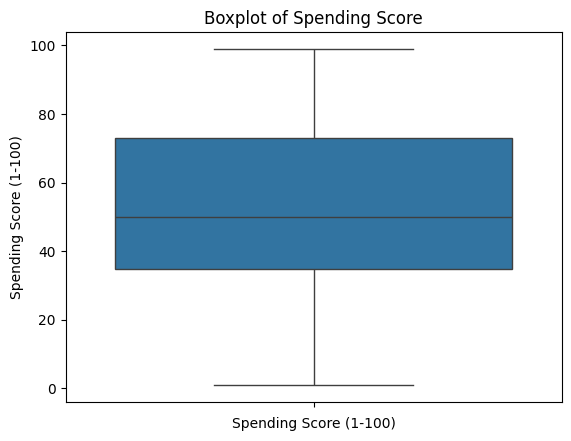

In [ ]:
sns.boxplot(df['Spending Score (1-100)'])
plt.title("Boxplot of Spending Score")
plt.xlabel("Spending Score (1-100)")
plt.show()

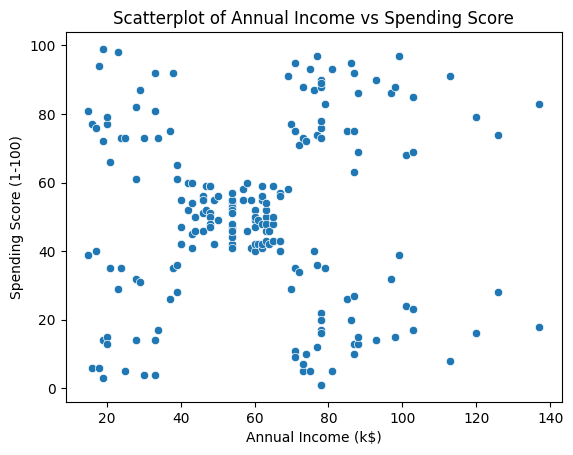

In [ ]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.title("Scatterplot of Annual Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

## Model Building


# identifying the number of clusters


In [ ]:
import numpy as np
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
  kmeans = KMeans(n_clusters = k, random_state=42)
  kmeans.fit(df)
  wcss.append(kmeans.inertia_)

print(wcss)

[269981.28000000014, 183653.3289473683, 106348.37306211119, 73880.64496247198, 44448.45544793369, 40825.16946386947, 33642.57922077922, 26686.837785187785, 24766.471609793436, 23103.122085983905]


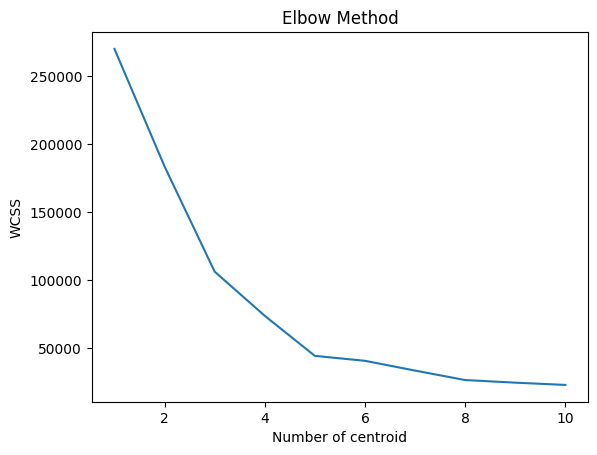

In [ ]:
plt.plot(range(1, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of centroid")
plt.ylabel("WCSS")
plt.show()

In [ ]:
y_kmeans = KMeans(n_clusters = 5, random_state=42)
kmeans = y_kmeans.fit_predict(df)

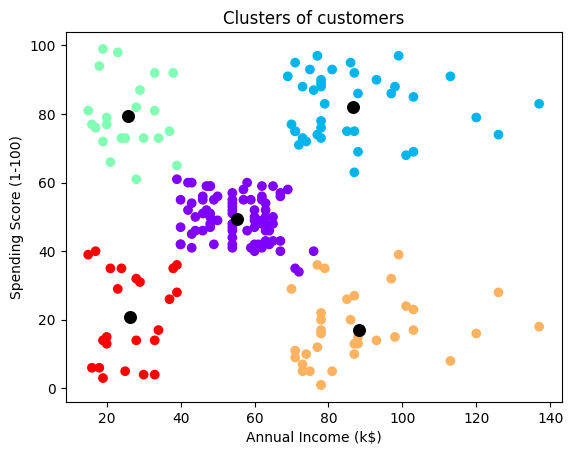

In [ ]:
plt.scatter(data = df, x= 'Annual Income (k$)', y = "Spending Score (1-100)", c = kmeans, cmap = 'rainbow')
plt.scatter(y_kmeans.cluster_centers_[:, 0],
            y_kmeans.cluster_centers_[:, 1],
            s = 70, c = 'black', label = 'Centroids')

plt.title("Clusters of customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

high income + high spending = premimum customer

high income + low spending = carefull buyer

low income + low spending = budget buyer

low income + high spending = young buyer

In [ ]:
df.head()

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,2
2,16,6,4
3,16,77,2
4,17,40,4
